In [1]:
# 런타임 재시작시
from google.colab import drive
import os, torch

drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/CProject/Fingerprint-recognition")

print("경로:", os.getcwd())
!git status

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Mounted at /content/drive
경로: /content/drive/MyDrive/CProject/Fingerprint-recognition
Refresh index: 100% (35/35), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    fingerprintTest.h5
	deleted:    fingerprintTest_original.h5
	deleted:    preprocess.ipynb
	deleted:    train.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	bfg-1.14.0.jar
	history/
	model/
	src_train/

no changes added to commit (use "git add" and/or "git commit -a")
CUDA: True
GPU: Tesla T4


In [2]:
%pwd

'/content/drive/MyDrive/CProject/Fingerprint-recognition'

In [3]:
!git add .
!git commit -m "v1_final"


Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@df97513c4cff.(none)')


In [4]:
!git config --global user.email "gpwnsla1215@naver.com”
!git config --global user.name "hizoo66"

/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [ ]:
!git push origin main

Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 67.50 KiB | 1.04 MiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/hizoo66/Fingerprint-recognition.git
   3cb9959..cab10da  main -> main


----------------

image Augmentation 모듈이 numpy 1.x 버전과 파이썬 3.11버전을 참조하기 때문에 버림...  
colab에서 파이썬 버전 변경 불가

In [ ]:
import numpy as np, matplotlib.pyplot as plt
import cv2
import random
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from keras import layers
from keras.models import Model, load_model
from tensorflow import keras

#Load Datatset




(6001, 96, 96, 1) (6001, 4)


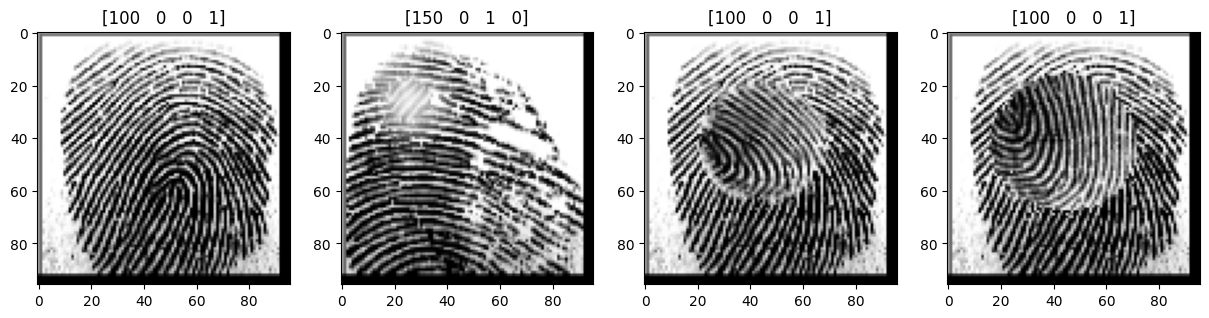

In [ ]:
x_real = np.load('dataset/x_real.npy')[..., np.newaxis]
y_real = np.load('dataset/y_real.npy')
x_easy = np.load('dataset/x_easy.npy')[..., np.newaxis]
y_easy = np.load('dataset/y_easy.npy')
x_medium = np.load('dataset/x_medium.npy')[..., np.newaxis]
y_medium = np.load('dataset/y_medium.npy')
x_hard = np.load('dataset/x_hard.npy')[..., np.newaxis]
y_hard = np.load('dataset/y_hard.npy')

print(x_real.shape, y_real.shape)

plt.figure(figsize=(15, 10))
plt.subplot(1, 4, 1)
plt.title(y_real[0])
plt.imshow(x_real[0].squeeze(), cmap='gray')
plt.subplot(1, 4, 2)
plt.title(y_easy[0])
plt.imshow(x_easy[0].squeeze(), cmap='gray')
plt.subplot(1, 4, 3)
plt.title(y_medium[0])
plt.imshow(x_medium[0].squeeze(), cmap='gray')
plt.subplot(1, 4, 4)
plt.title(y_hard[0])
plt.imshow(x_hard[0].squeeze(), cmap='gray')

#테두리를 없애기위한 Crop 과정

In [ ]:
# 1. Crop 함수 (중앙 90x90)
def center_crop(img, crop_size=88):
    h, w = img.shape[:2]
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return img[start_h:start_h+crop_size, start_w:start_w+crop_size]

(6001, 88, 88, 1) (6001, 4)


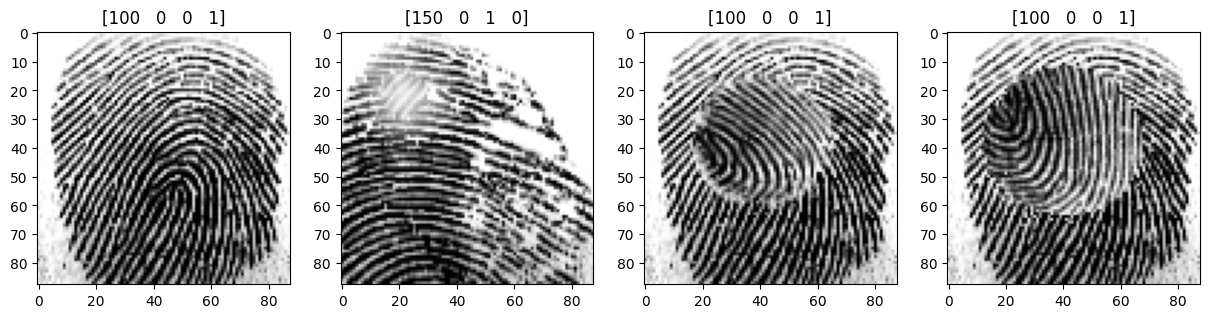

In [ ]:
x_real_cropped = np.array([center_crop(img) for img in x_real])
x_easy_cropped = np.array([center_crop(img) for img in x_easy])
x_medium_cropped = np.array([center_crop(img) for img in x_medium])
x_hard_cropped = np.array([center_crop(img) for img in x_hard])

print(x_real_cropped.shape, y_real.shape)

plt.figure(figsize=(15, 10))
plt.subplot(1, 4, 1)
plt.title(y_real[0])
plt.imshow(x_real_cropped[0].squeeze(), cmap='gray')
plt.subplot(1, 4, 2)
plt.title(y_easy[0])
plt.imshow(x_easy_cropped[0].squeeze(), cmap='gray')
plt.subplot(1, 4, 3)
plt.title(y_medium[0])
plt.imshow(x_medium_cropped[0].squeeze(), cmap='gray')
plt.subplot(1, 4, 4)
plt.title(y_hard[0])
plt.imshow(x_hard_cropped[0].squeeze(), cmap='gray')

# Split Data

In [ ]:
x_data = np.concatenate([x_easy_cropped, x_medium_cropped, x_hard_cropped], axis=0)
label_data = np.concatenate([y_easy, y_medium, y_hard], axis=0)

x_train, x_val, label_train, label_val = train_test_split(x_data, label_data, test_size=0.1)

print(x_data.shape, label_data.shape)
print(x_train.shape, label_train.shape)
print(x_val.shape, label_val.shape)

(47605, 88, 88, 1) (47605, 4)
(42844, 88, 88, 1) (42844, 4)
(4761, 88, 88, 1) (4761, 4)


# Augmentation 모듈 대신 만든 함수
-> 이 함수는 Datagenerator 에서 학습과 동시에 데이터 생성시 사용됩니다.
1. GaussianBlur  
2. Affine transform: scale, rotate, translate

In [ ]:

def augment_image(img):
    h, w = img.shape[:2]
    # Gaussian blur
    sigma = random.uniform(0, 1.5)
    if sigma > 0:
        img = cv2.GaussianBlur(img, (3, 3), sigma)

    # Affine transform: scale, rotate, translate
    scale_x = random.uniform(0.9, 1.1)
    scale_y = random.uniform(0.9, 1.1)
    angle = random.uniform(-30, 30)
    tx = random.uniform(-0.1, 0.1) * w
    ty = random.uniform(-0.1, 0.1) * h

    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    M[0,0] *= scale_x
    M[0,1] *= scale_x
    M[1,0] *= scale_y
    M[1,1] *= scale_y
    M[0,2] += tx
    M[1,2] += ty

    img_aug = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=255)
    return img_aug

# Augmentation Preview

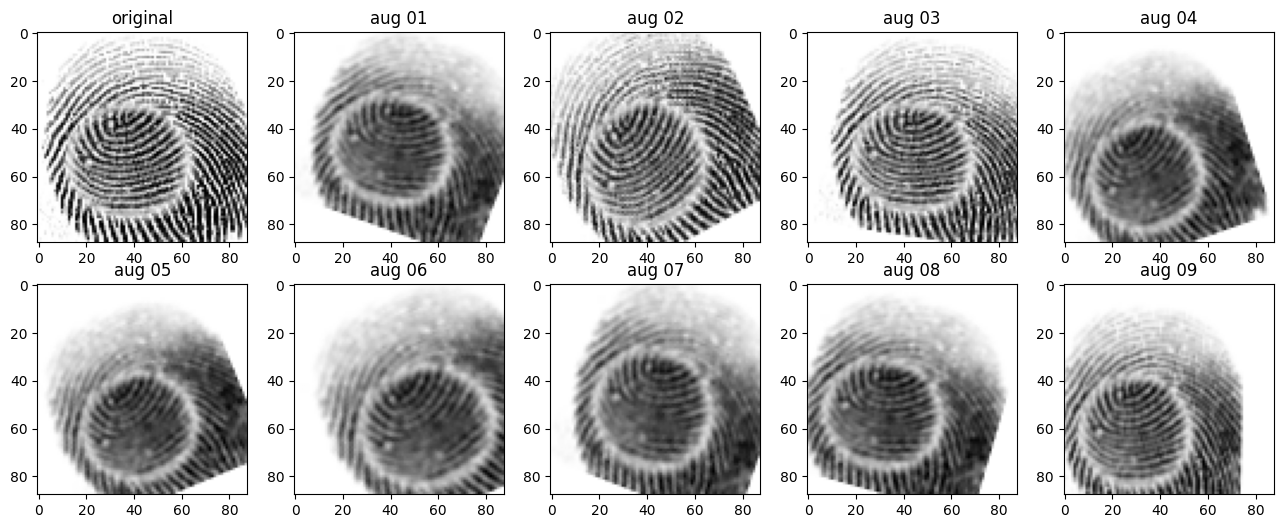

In [ ]:
sample_img = x_data[40000]  # (H, W, 1) 또는 (H, W)

# 9개의 augmented 이미지 만들기
augs = [augment_image(sample_img.squeeze()) for _ in range(9)]

# 시각화
plt.figure(figsize=(16, 6))
plt.subplot(2, 5, 1)
plt.title('original')
plt.imshow(sample_img.squeeze(), cmap='gray')

for i, aug in enumerate(augs):
    plt.subplot(2, 5, i+2)
    plt.title(f'aug {i+1:02d}')
    plt.imshow(aug, cmap='gray')  # 이미 augment_image에서 (H, W)로 나옴

plt.show()

# Make Label Dictionary Lookup Table

In [ ]:
label_real_dict = {}

for i, y in enumerate(y_real):
    key = y.astype(str)
    key = ''.join(key).zfill(6)

    label_real_dict[key] = i

# DataGenerator


In [ ]:
class DataGenerator(keras.utils.Sequence):
    def __init__(self, x, label, x_real, label_real_dict, batch_size=32, shuffle=True):
        'Initialization'
        self.x = x
        self.label = label
        self.x_real = x_real
        self.label_real_dict = label_real_dict

        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.x) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        x1_batch = self.x[index*self.batch_size:(index+1)*self.batch_size]
        label_batch = self.label[index*self.batch_size:(index+1)*self.batch_size]

        x2_batch = np.empty((self.batch_size, 88, 88, 1), dtype=np.float32)  # 88로 변경
        y_batch = np.zeros((self.batch_size, 1), dtype=np.float32)

        # augmentation
        if self.shuffle:
            x1_batch_aug = np.empty_like(x1_batch, dtype=np.float32)
            for i, img in enumerate(x1_batch):
                x1_batch_aug[i, :, :, 0] = augment_image(img.squeeze())  # 1채널만 전달
            x1_batch = x1_batch_aug

        # pick matched/unmatched images
        for i, l in enumerate(label_batch):
            match_key = l.astype(str)
            match_key = ''.join(match_key).zfill(6)

            if random.random() > 0.5:
                x2_batch[i] = self.x_real[self.label_real_dict[match_key]] # Corrected line
                y_batch[i] = 1.
            else:
                while True:
                    unmatch_key, unmatch_idx = random.choice(list(self.label_real_dict.items()))
                    if unmatch_key != match_key:
                        break
                x2_batch[i] = self.x_real[unmatch_idx] # Corrected line
                y_batch[i] = 0.

        return (x1_batch / 255., x2_batch / 255.), y_batch

    def on_epoch_end(self):
        if self.shuffle:
            self.x, self.label = shuffle(self.x, self.label)

In [ ]:
train_gen = DataGenerator(x_train, label_train, x_real_cropped, label_real_dict, shuffle=True)
val_gen = DataGenerator(x_val, label_val, x_real_cropped, label_real_dict, shuffle=False)

# Create Model

In [ ]:
x1 = layers.Input(shape=(88, 88, 1))
x2 = layers.Input(shape=(88, 88, 1))

# share weights both inputs
inputs = layers.Input(shape=(88, 88, 1))

feature = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(inputs)
feature = layers.MaxPooling2D(pool_size=2)(feature)

feature = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(feature)
feature = layers.MaxPooling2D(pool_size=2)(feature)

feature_model = Model(inputs=inputs, outputs=feature)

# 2 feature models that sharing weights
x1_net = feature_model(x1)
x2_net = feature_model(x2)

# subtract features
net = layers.Subtract()([x1_net, x2_net])

net = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(net)
net = layers.MaxPooling2D(pool_size=2)(net)

net = layers.Flatten()(net)

net = layers.Dense(64, activation='relu')(net)

net = layers.Dense(1, activation='sigmoid')(net)

model = Model(inputs=[x1, x2], outputs=net)

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 88, 88, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 88, 88, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ (None, 22, 22,    │      9,568 │ input_layer_3[0]… │
│ (Functional)        │ 32)               │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 22, 22,    │          0 │ functional_2[0][… │
│ (Subtract)          │ 32)               │            │ functional_2[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 22, 22,    │      9,248 │ subtract_1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 11, 11,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3872)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │    247,872 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 266,753 (1.02 MB)

 Trainable params: 266,753 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

# Train

In [ ]:
history = model.fit(train_gen, epochs=15, validation_data=val_gen)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1338/1338 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - acc: 0.8345 - loss: 0.3510 - val_acc: 0.9698 - val_loss: 0.0654
Epoch 2/15
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - acc: 0.9298 - loss: 0.1755 - val_acc: 0.9740 - val_loss: 0.0588
Epoch 3/15
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - acc: 0.9453 - loss: 0.1399 - val_acc: 0.9884 - val_loss: 0.0313
Epoch 4/15
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - acc: 0.9519 - loss: 0.1215 - val_acc: 0.9865 - val_loss: 0.0340
Epoch 5/15
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - acc: 0.9571 - loss: 0.1126 - val_acc: 0.9831 - val_loss: 0.0363
Epoch 6/15
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - acc: 0.9627 - loss: 0.1042 - val_acc: 0.9859 - val_loss: 0.0321
Epoch 7/15
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - acc: 0.9654 - loss: 0.0931 - val_acc: 0.9873 - val_loss: 0.0277
Epoch 8/15
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - acc: 0.9690 - loss: 0.0858 - val_acc: 0.9880 - val_loss: 0.0322
Epoch 9/15
1338/1338 ━━━━━━━━━━━━━━

# 성능 분석
1. 시각화
2. 모델 저장

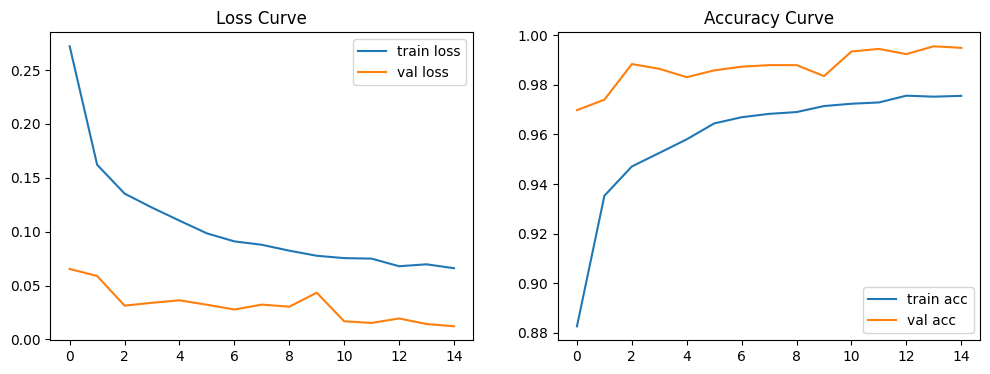

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(history.history['acc'], label='train acc')
plt.plot(history.history['val_acc'], label='val acc')
plt.legend()
plt.title('Accuracy Curve')

plt.show()


In [ ]:
# 실제 성능 검증
def verify_fingerprint(img1, img2, threshold=0.5):
    p = model.predict([img1[np.newaxis]/255., img2[np.newaxis]/255.])[0][0]
    return p, int(p > threshold)

score, result = verify_fingerprint(x_real_cropped[0], x_real_cropped[3])
print("Match score:", score)
print("Result:", "MATCH" if result else "NOT MATCH")



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
Match score: 0.7923868
Result: MATCH


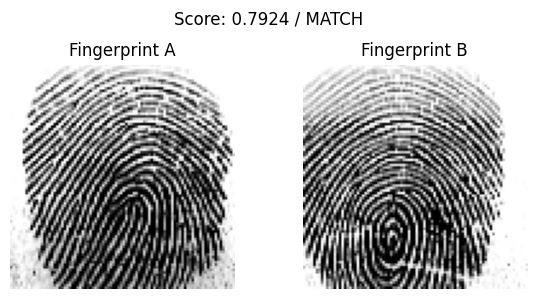

In [ ]:
# 시각화
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.title("Fingerprint A")
plt.imshow(x_real_cropped[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Fingerprint B")
plt.imshow(x_real_cropped[3].squeeze(), cmap='gray')
plt.axis('off')

plt.suptitle(f"Score: {score:.4f} / {'MATCH' if result else 'NOT MATCH'}", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
model.save("model/finger_model_v1.keras")

#epochs = 50 학습 및 성능 평가

In [ ]:
# epochs = 50
history2 = model.fit(train_gen, epochs=50, validation_data=val_gen)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1338/1338 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - acc: 0.8076 - loss: 0.3810 - val_acc: 0.9662 - val_loss: 0.1004
Epoch 2/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - acc: 0.9252 - loss: 0.1921 - val_acc: 0.9802 - val_loss: 0.0544
Epoch 3/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - acc: 0.9433 - loss: 0.1504 - val_acc: 0.9766 - val_loss: 0.0600
Epoch 4/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - acc: 0.9521 - loss: 0.1269 - val_acc: 0.9837 - val_loss: 0.0426
Epoch 5/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - acc: 0.9564 - loss: 0.1147 - val_acc: 0.9789 - val_loss: 0.0518
Epoch 6/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - acc: 0.9586 - loss: 0.1088 - val_acc: 0.9871 - val_loss: 0.0353
Epoch 7/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - acc: 0.9659 - loss: 0.0969 - val_acc: 0.9804 - val_loss: 0.0487
Epoch 8/50
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - acc: 0.9653 - loss: 0.0910 - val_acc: 0.9873 - val_loss: 0.0381
Epoch 9/50
1338/1338 ━━━━━━━━━━━━━━

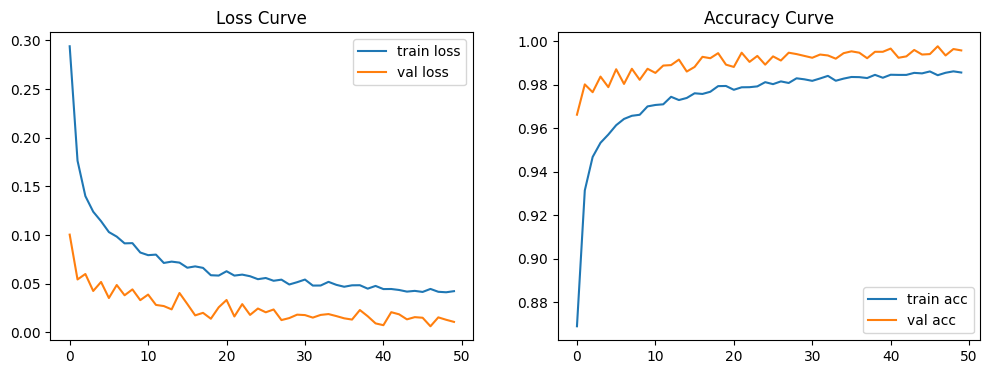

In [ ]:
# 시각화
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history2.history['loss'], label='train loss')
plt.plot(history2.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(history2.history['acc'], label='train acc')
plt.plot(history2.history['val_acc'], label='val acc')
plt.legend()
plt.title('Accuracy Curve')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Match score: 0.0016675513
Result: NOT MATCH


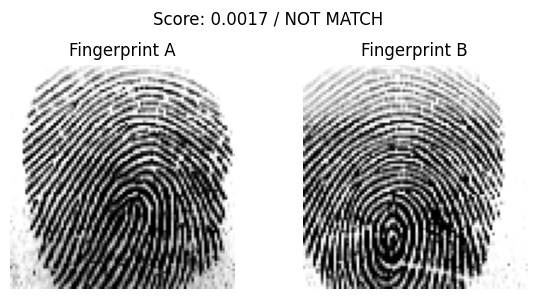

In [ ]:
# 실제 성능 검증
score, result = verify_fingerprint(x_real_cropped[0], x_real_cropped[3])
print("Match score:", score)
print("Result:", "MATCH" if result else "NOT MATCH")

# 시각화
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.title("Fingerprint A")
plt.imshow(x_real_cropped[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Fingerprint B")
plt.imshow(x_real_cropped[3].squeeze(), cmap='gray')
plt.axis('off')

plt.suptitle(f"Score: {score:.4f} / {'MATCH' if result else 'NOT MATCH'}", fontsize=12)
plt.tight_layout()
plt.show()



In [ ]:
# 모델, 히스토리 저장
model.save("model/finger_model_v1_2.keras")
np.save(f'history/history_v1_2.npy', history2.history)

# epochs=100 학습 및 성능 평가

In [ ]:
# epochs = 100
history = model.fit(train_gen, epochs=100, validation_data=val_gen)

Epoch 1/100
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - acc: 0.8203 - loss: 0.3668 - val_acc: 0.9728 - val_loss: 0.0693
Epoch 2/100
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - acc: 0.9275 - loss: 0.1817 - val_acc: 0.9852 - val_loss: 0.0333
Epoch 3/100
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - acc: 0.9403 - loss: 0.1539 - val_acc: 0.9867 - val_loss: 0.0314
Epoch 4/100
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - acc: 0.9509 - loss: 0.1308 - val_acc: 0.9854 - val_loss: 0.0387
Epoch 5/100
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - acc: 0.9544 - loss: 0.1201 - val_acc: 0.9816 - val_loss: 0.0440
Epoch 6/100
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - acc: 0.9612 - loss: 0.1061 - val_acc: 0.9901 - val_loss: 0.0250
Epoch 7/100
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - acc: 0.9620 - loss: 0.1006 - val_acc: 0.9854 - val_loss: 0.0349
Epoch 8/100
1338/1338 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - acc: 0.9634 - loss: 0.0979 - val_acc: 0.9911 - val_loss: 0.0215
Epoch 9/100
1338

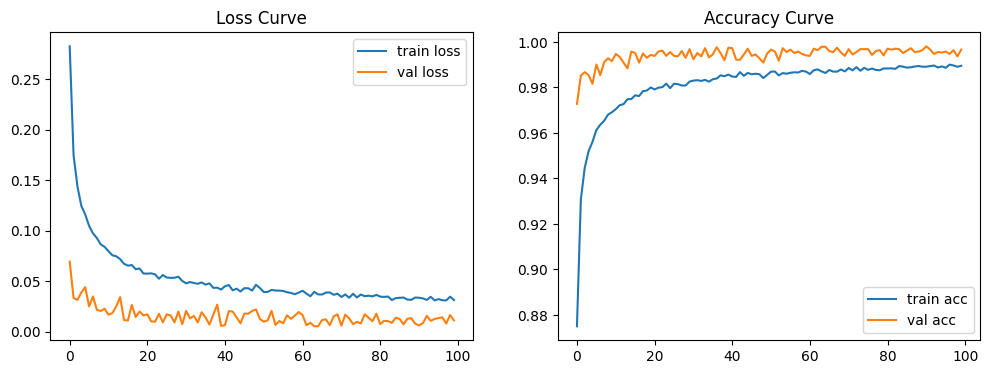

In [ ]:
# 시각화
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(history.history['acc'], label='train acc')
plt.plot(history.history['val_acc'], label='val acc')
plt.legend()
plt.title('Accuracy Curve')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
Match score: 0.055680383
Result: NOT MATCH


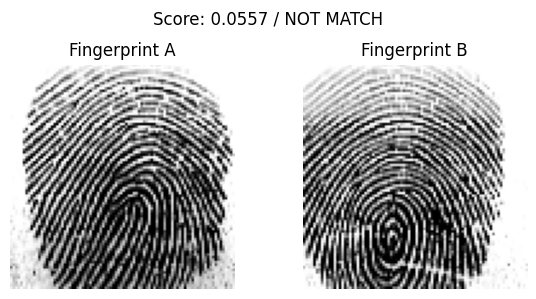

In [ ]:
# 실제 성능 검증

score, result = verify_fingerprint(x_real_cropped[0], x_real_cropped[3])
print("Match score:", score)
print("Result:", "MATCH" if result else "NOT MATCH")

# 시각화
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.title("Fingerprint A")
plt.imshow(x_real_cropped[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Fingerprint B")
plt.imshow(x_real_cropped[3].squeeze(), cmap='gray')
plt.axis('off')

plt.suptitle(f"Score: {score:.4f} / {'MATCH' if result else 'NOT MATCH'}", fontsize=12)
plt.tight_layout()
plt.show()



In [ ]:
# 모델 저장
model.save("model/finger_model_v1_3.keras")
np.save(f'history/history_v1_3.npy', history.history)

---

# Test 데이터 활용하여 FAR, FRR 평가
### 1. 각 모델별 최적의 threshold값 찾기:  
- threshold 값 0-1사이에서 FAR, FRR 수치 시각화
- 찾은 threshold값 출력, 그 때 FAR, FRR 수치 출력

### 2. 임의의 Test쌍 5개 골라서 모델별 실제 테스트
- 동일한 쌍 2개, 다른 쌍 3개 : 예측값, 결과 출력
- 각 모델별로 최적의 threshold로 적용, 동일한 데이터 셋으로 비교

### +
- 외부 데이터 셋 테스트

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Model 1: EER threshold=0.850, FAR=0.000, FRR=0.000, AUC=1.000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Model 2: EER threshold=0.950, FAR=0.000, FRR=0.000, AUC=1.000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Model 3: EER threshold=0.490, FAR=0.000, FRR=0.000, AUC=1.000


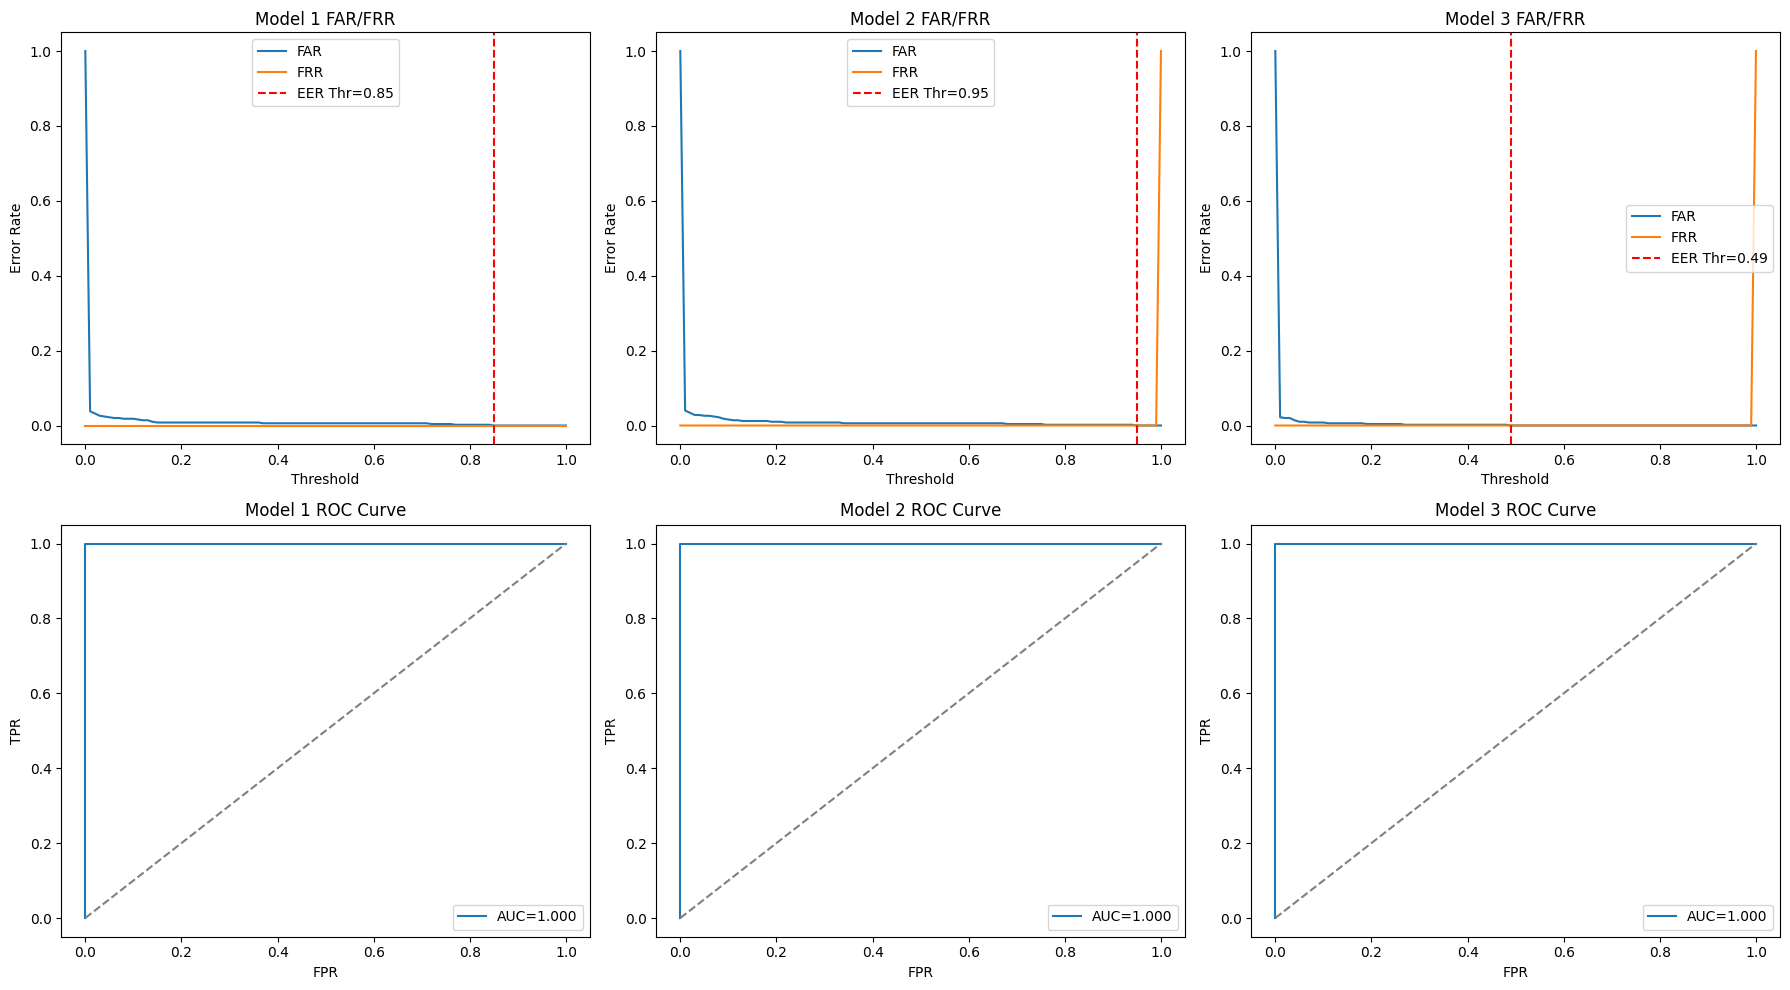

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_curve, auc

def center_crop(img, crop_size=88):
    h, w = img.shape[:2]
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return img[start_h:start_h+crop_size, start_w:start_w+crop_size]

model_paths = [
    "model/finger_model_v1.keras",
    "model/finger_model_v1_2.keras",
    "model/finger_model_v1_3.keras"
]

x_test = np.load('dataset/x_real.npy')[..., np.newaxis]
y_test = np.load('dataset/y_real.npy')
x_test_cropped = np.array([center_crop(img) for img in x_test])

num_samples = 1000
x_test1, x_test2, y_test_pairs = [], [], []

# 동일 쌍
for _ in range(num_samples // 2):
    idx = np.random.randint(0, len(x_test_cropped))
    x_test1.append(x_test_cropped[idx])
    x_test2.append(x_test_cropped[idx])
    y_test_pairs.append(1)

# 다른 쌍
for _ in range(num_samples // 2):
    idx1, idx2 = np.random.choice(len(x_test_cropped), size=2, replace=False)
    x_test1.append(x_test_cropped[idx1])
    x_test2.append(x_test_cropped[idx2])
    y_test_pairs.append(0)

x_test1 = np.array(x_test1) / 255.0
x_test2 = np.array(x_test2) / 255.0
y_test_pairs = np.array(y_test_pairs)


models = [load_model(p) for p in model_paths]
thresholds = np.linspace(0, 1, 101)
results = {}

for i, model in enumerate(models):
    preds = model.predict([x_test1, x_test2], batch_size=32).flatten()

    FAR_list, FRR_list = [], []
    for t in thresholds:
        preds_bin = (preds >= t).astype(int)
        FAR = np.sum((preds_bin == 1) & (y_test_pairs == 0)) / np.sum(y_test_pairs == 0)
        FRR = np.sum((preds_bin == 0) & (y_test_pairs == 1)) / np.sum(y_test_pairs == 1)
        FAR_list.append(FAR)
        FRR_list.append(FRR)

    eer_idx = np.argmin(np.abs(np.array(FAR_list) - np.array(FRR_list)))
    eer_threshold = thresholds[eer_idx]
    eer_far = FAR_list[eer_idx]
    eer_frr = FRR_list[eer_idx]

    fpr, tpr, _ = roc_curve(y_test_pairs, preds)
    roc_auc = auc(fpr, tpr)

    results[f'Model_{i+1}'] = {
        'preds': preds,
        'FAR_list': FAR_list,
        'FRR_list': FRR_list,
        'thresholds': thresholds,
        'EER_threshold': eer_threshold,
        'EER_FAR': eer_far,
        'EER_FRR': eer_frr,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }

    print(f"Model {i+1}: EER threshold={eer_threshold:.3f}, FAR={eer_far:.3f}, FRR={eer_frr:.3f}, AUC={roc_auc:.3f}")

#시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i in range(3):
    res = results[f'Model_{i+1}']

    # 1행
    ax = axes[0, i]
    ax.plot(res['thresholds'], res['FAR_list'], label='FAR')
    ax.plot(res['thresholds'], res['FRR_list'], label='FRR')
    ax.axvline(res['EER_threshold'], color='red', linestyle='--', label=f'EER Thr={res["EER_threshold"]:.2f}')
    ax.set_title(f'Model {i+1} FAR/FRR')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Error Rate')
    ax.legend()

    # 2행
    ax = axes[1, i]
    ax.plot(res['fpr'], res['tpr'], label=f'AUC={res["roc_auc"]:.3f}')
    ax.plot([0,1],[0,1],'--', color='gray')
    ax.set_title(f'Model {i+1} ROC Curve')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend()

plt.tight_layout()
plt.show()
